<a href="https://colab.research.google.com/github/jahnavitelsang/Assignment2026/blob/main/MLR_assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Assignment Task: Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.
#1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/ToyotaCorolla_-_MLR[1].csv')
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.shape

(1436, 11)

In [5]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [7]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [8]:
#There are no null values in this dataset .

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
# Lets perform visualizations

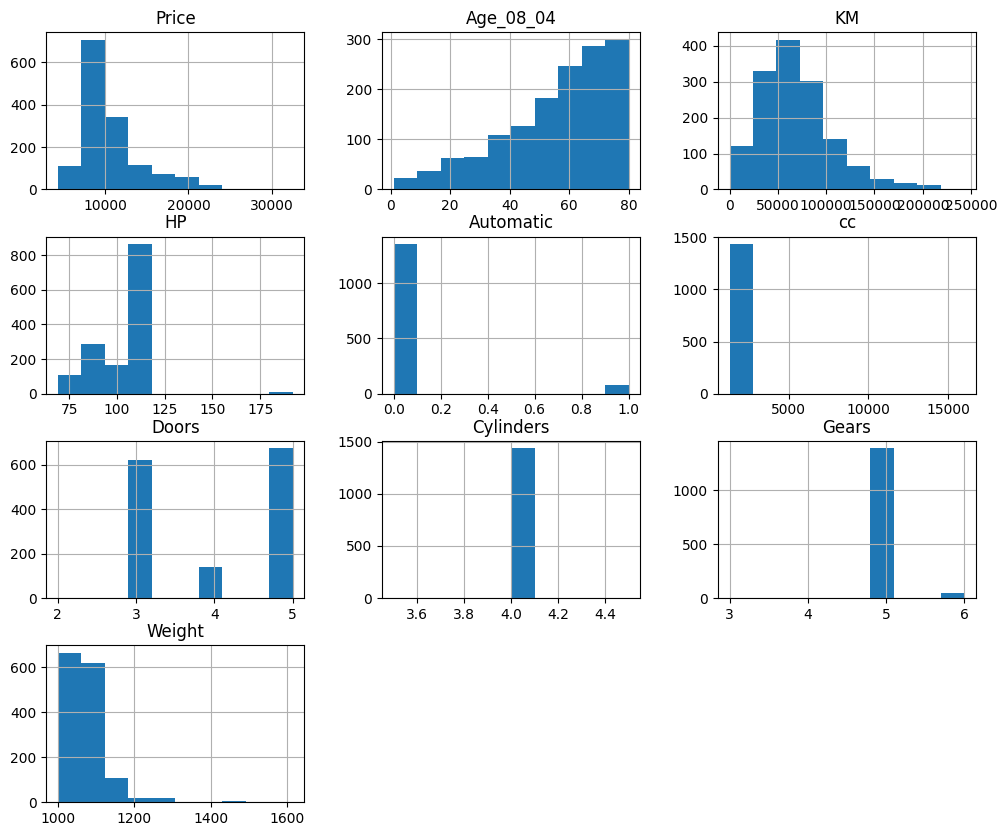

In [12]:
df.hist(figsize=(12,10))
plt.show()     #To check distribution and the skewing

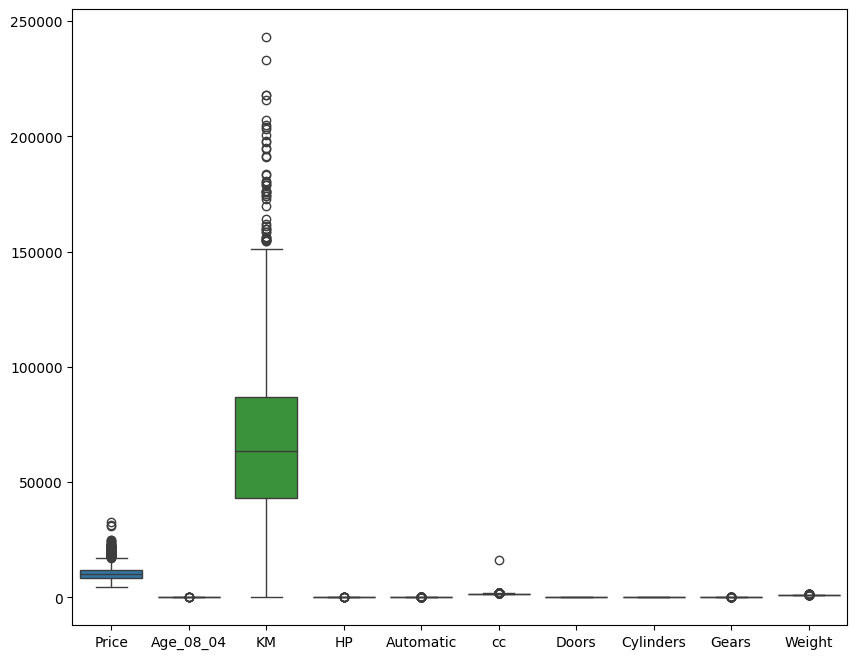

In [13]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df)
plt.xticks()
plt.show()         #mainly to detect outliers

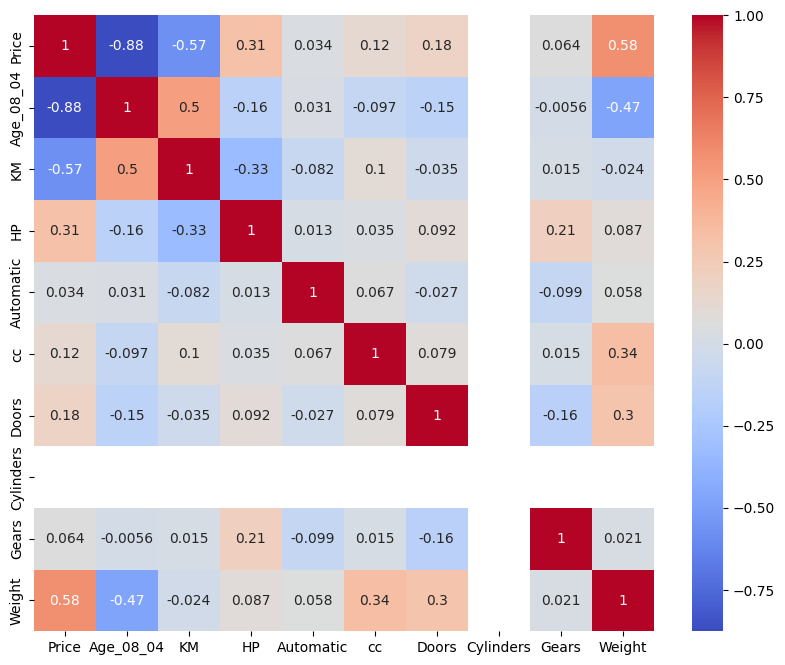

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()     # Positive correlation , Negative correlation ,Multicollineari

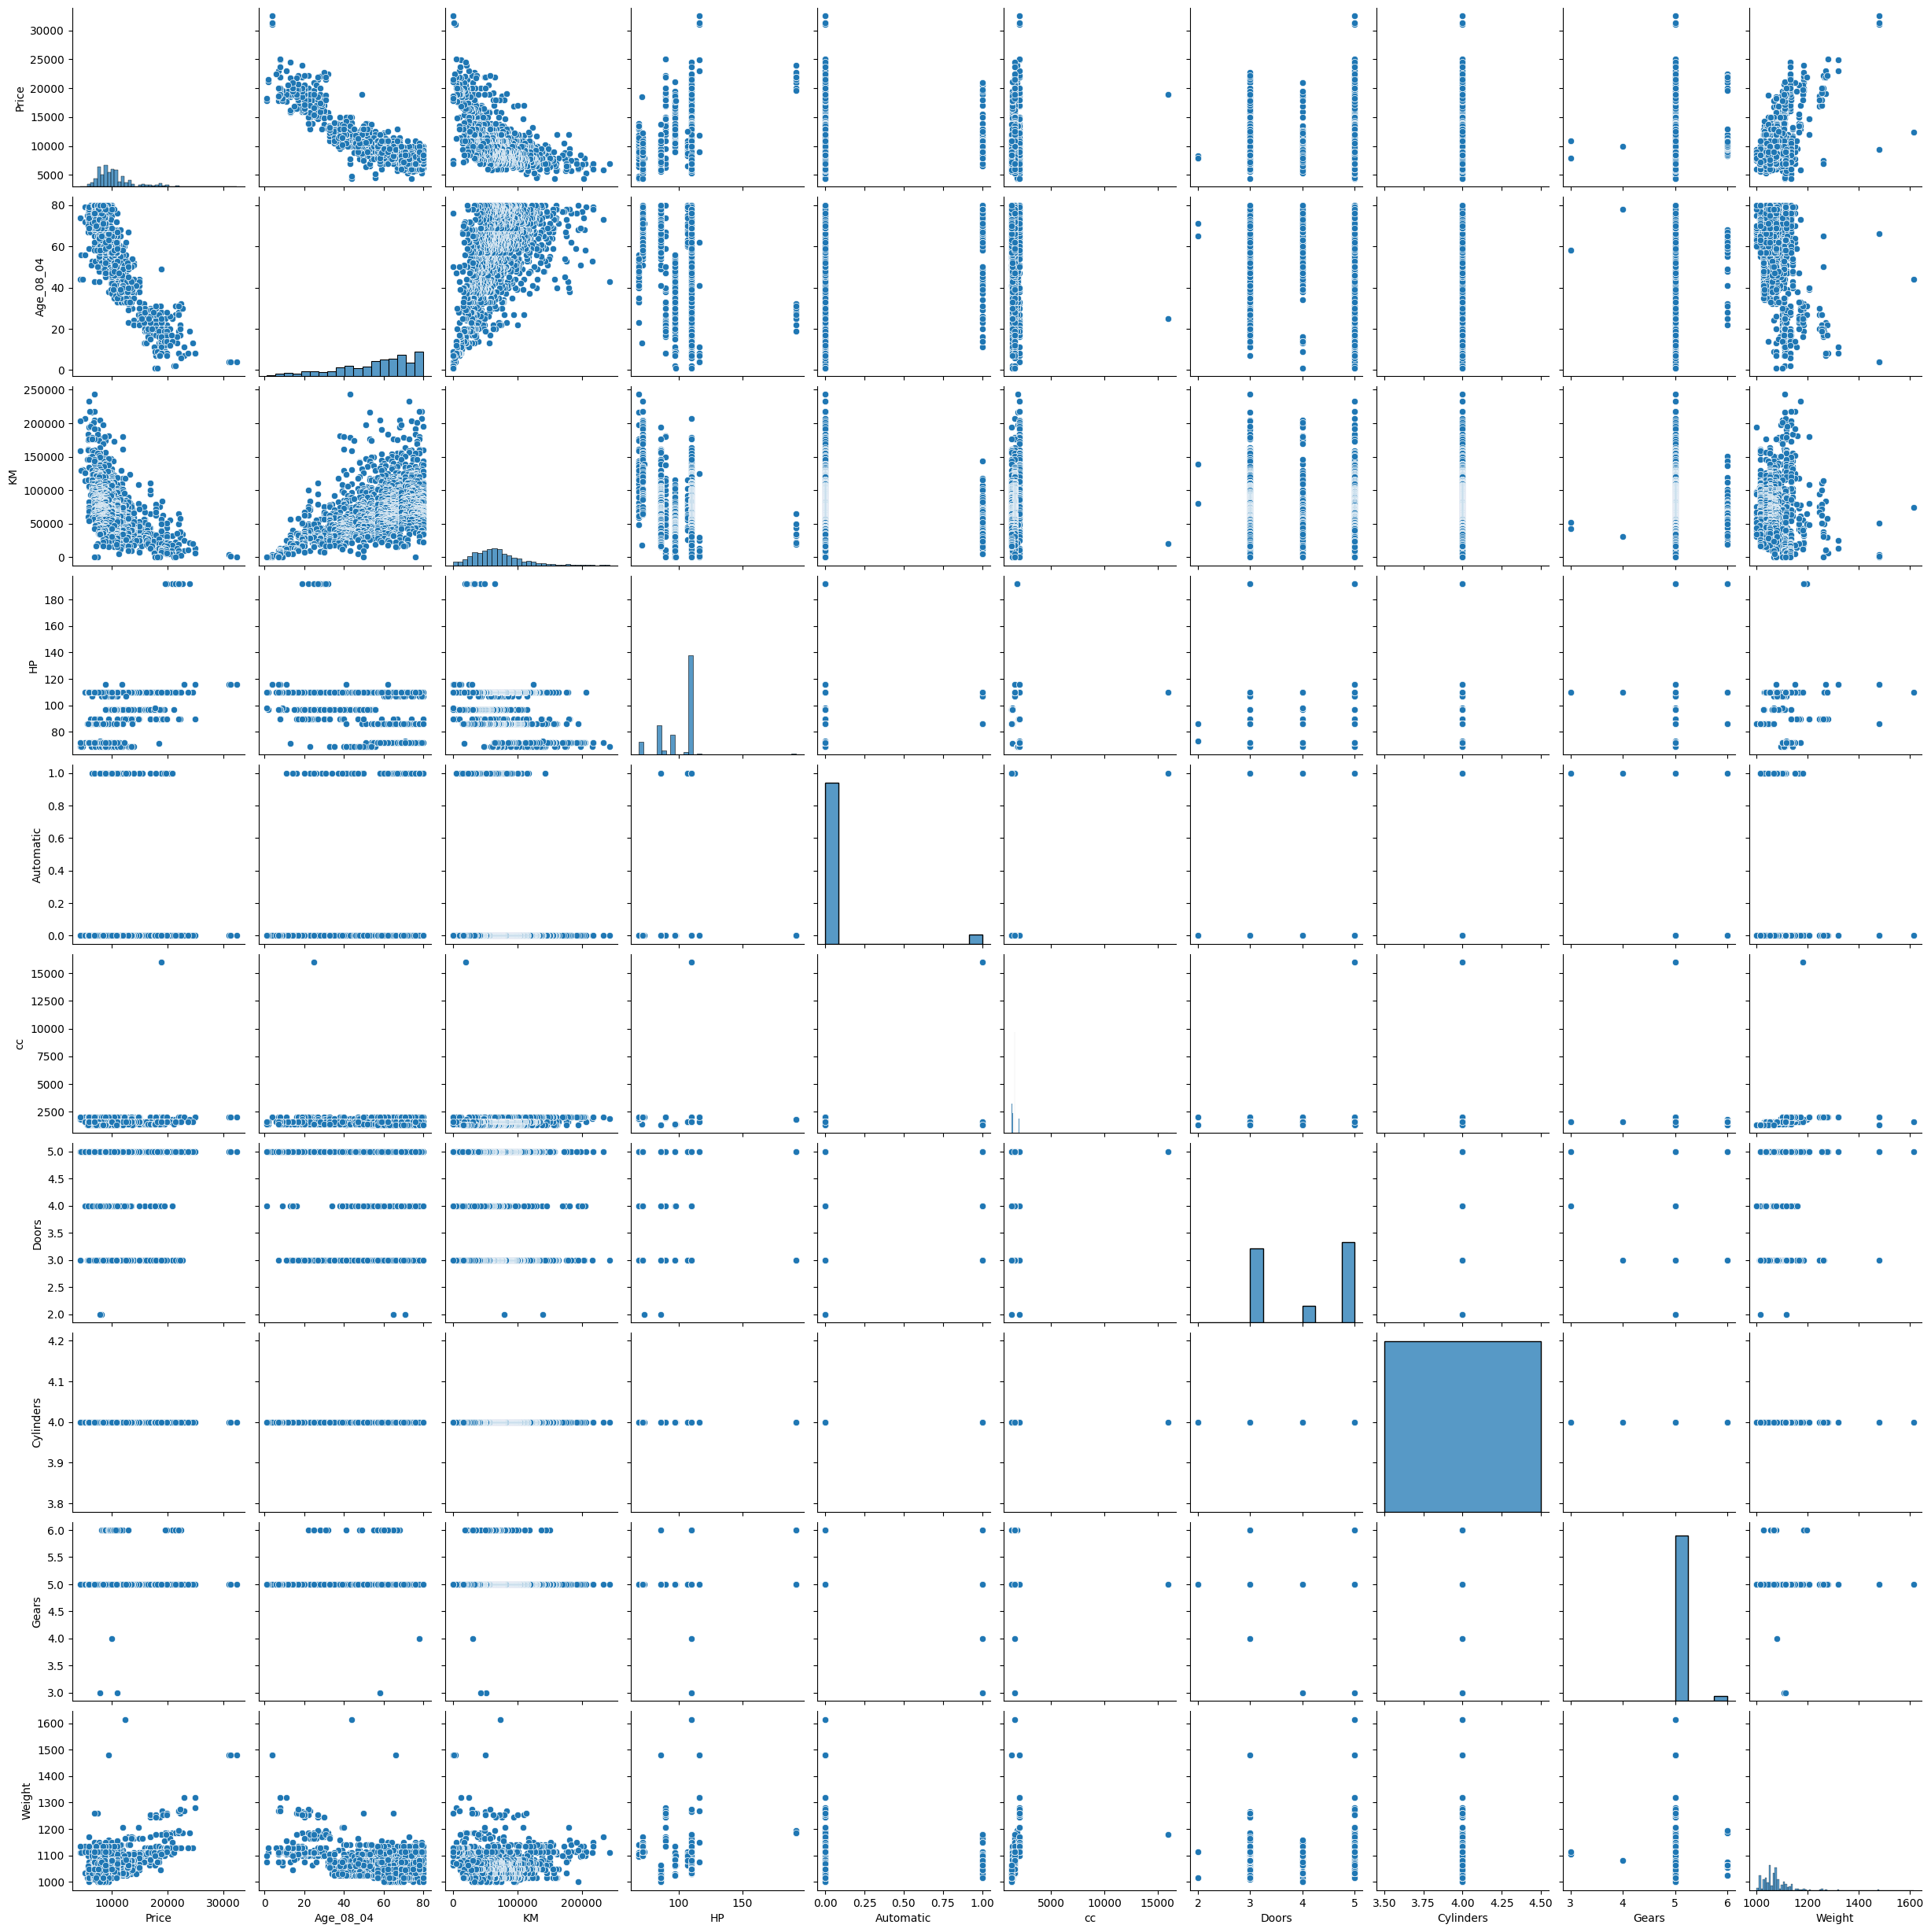

In [15]:
sns.pairplot(df)
plt.show()    #shows relationship between the variables

In [16]:
# Now lets preprocess the data , as there is categorical values

In [17]:
df = pd.get_dummies(df,
                    columns=["Fuel_Type"],
                    drop_first=True)
df = df.astype(int)
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,1,0
1,13750,23,72937,90,0,2000,3,4,5,1165,1,0
2,13950,24,41711,90,0,2000,3,4,5,1165,1,0
3,14950,26,48000,90,0,2000,3,4,5,1165,1,0
4,13750,30,38500,90,0,2000,3,4,5,1170,1,0


In [18]:
# Now to traina nd test the data , lets set the target variables
x = df.drop('Price',axis = 1)
y = df['Price']

In [19]:
#2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.20,random_state=42)

In [21]:
#3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [22]:
# Model 1
from sklearn.linear_model import LinearRegression

In [23]:
model1 = LinearRegression()
model1.fit(x_train,y_train)
pred1 = model1.predict(x_test)


In [24]:
#Model2
x2 = df[['Age_08_04', 'KM','HP','Weight']]
x2_train,x2_test,y_train,y_test = train_test_split(x2,y,test_size = 0.20,random_state=42)
model2 = LinearRegression()
model2.fit(x2_train,y_train)
pred2 = model2.predict(x2_test)



In [25]:
#Model3
x3 = df[['Age_08_04','Weight','Doors']]
x3_train,x3_test,y_train,y_test = train_test_split(x3,y,test_size = 0.20,random_state=42)
model3 = LinearRegression()
model3.fit(x3_train,y_train)
pred3 = model3.predict(x3_test)

In [26]:
coef = pd.DataFrame({
    "Feature": x2_train.columns,
    "Coefficient": model2.coef_
})

print(coef)

     Feature  Coefficient
0  Age_08_04  -120.619071
1         KM    -0.020074
2         HP    31.478589
3     Weight    19.847999


In [27]:
#In the above interpretation , when age decreases every year , the price drops by 120 euros
# everyhorse power , price increases bt 31.478 euros
# the more the weight , the price incraese by 19.847999

In [28]:
#Model Evaluation
# Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [32]:
mae = mean_absolute_error(y_test,pred1)
mse = mean_squared_error(y_test,pred1)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,pred1)
mae

986.4966877482506

In [33]:
mse

2155628.3561396236

In [34]:
rmse

np.float64(1468.205828942122)

In [35]:
r2

0.8203213869961808

In [30]:
# 91% of the variation in car price is explained by the model.

In [36]:
# MODEL 2
mae = mean_absolute_error(y_test,pred2)
mse = mean_squared_error(y_test,pred2)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,pred2)

In [37]:
mae

987.225283393743

In [38]:
mse

1934478.8193824275

In [39]:
rmse

np.float64(1390.8554272038584)

In [40]:
r2

0.8387549179514566

In [ ]:
# MODEL 3

In [51]:
mae = mean_absolute_error(y_test,pred3)
mse = mean_squared_error(y_test,pred3)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,pred3)

In [52]:
mae

1110.417076370252

In [53]:
mse

2417785.0972684394

In [54]:
rmse

np.float64(1554.922858944597)

In [55]:
r2

0.7984697725926746

In [ ]:
# we should always choose the highest r2, so that it explains us how close the predicted mdoel is with the actual model .
# Model 2 is the best model .

In [ ]:
#5.Apply Lasso and Ridge methods on the model.

In [62]:
from sklearn.linear_model import Lasso ,Ridge
from sklearn.metrics import r2_score

In [64]:
lasso_model = Lasso()
ridge_model = Ridge()
lasso_model.fit(x_train,y_train)
ridge_model.fit(x_train,y_train)
lasso_pred = lasso_model.predict(x_test)
ridge_pred = ridge_model.predict(x_test)
print(r2_score(y_test,lasso_pred))
print(r2_score(y_test,ridge_pred))

0.8210480708679172
0.8205816343653275


In [ ]:
MAE: Average error.
RMSE: Gives extra weight to large errors.
R²: How much variation the model explains.

In [ ]:
# Three Multiple Linear Regression models are developed using different combinations
# The models were evaluated using MAE, MSE, RMSE, and R² score.
# Model 2, which used all available features, achieved the best predictive performance with the highest R² score .

In [ ]:
# Both Normalization and Standardization are feature scaling techniques.
#They transform numerical data so that features are on a comparable scale.
#Algorithms that depend on distances or optimization can become biased toward larger-scale features so it is vey important for the dataset to be normalized .

In [ ]:
# Techniques to Handle Multicollinearity
# Technique 1: Remove Highly Correlated Features
#Technique 2: Feature Selection
#Technique 3: Principal Component Analysis (PCA) it transforms correlated variables into a smaller set of uncorrelated principal components.
#Technique 4: Ridge Regression - It shrinks coefficient values, making the model more stable while keeping all features.
#Technique 5: Lasso Regression -It can shrink some coefficients to exactly zero, effectively removing less important features.

In [ ]:
#A linear relationship exists between the independent variables (Age, KM, HP, Weight, etc.) and the dependent variable (Price).
#Allthe  observations are independent of one another.
#The residuals have constant variance (homoscedasticity).
#The residuals are approximately normally distributed.
#Independent variables do not exhibit severe multicollinearity.
#No influential outliers remain after data preprocessing.